In [1]:
# Data Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_excel("/content/cleaned_Twitter_Full1.xlsx")

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove non-alphabetic characters (punctuation, numbers, etc.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning
data['cleaned_text'] = data['text'].apply(clean_text)

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['cleaned_text'].tolist(), data['labels'].tolist(), test_size=0.2, random_state=42
)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(val_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=150)  # Increased sequence length
X_test_pad = pad_sequences(X_test_seq, maxlen=150)

y_train = np.array(train_labels, dtype=np.float32)
y_test = np.array(val_labels, dtype=np.float32)

X_train_pad = np.array(X_train_pad, dtype=np.float32)
X_test_pad = np.array(X_test_pad, dtype=np.float32)

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")

# Class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: weight for i, weight in enumerate(class_weights)}


Shape of X_train_pad: (9008, 150)
Shape of X_test_pad: (2252, 150)


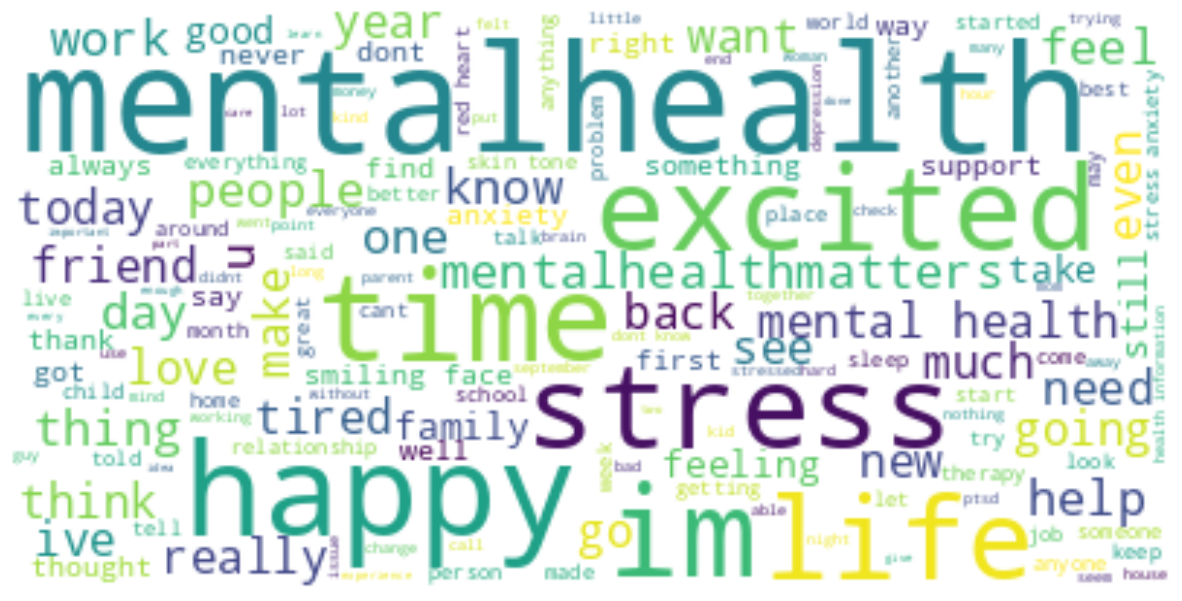

In [2]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
text = " ".join(i for i in data.text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords,
                      background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [4]:
# Load GloVe Embeddings
def load_glove_embeddings(embedding_dim, vocab_size, word_index):
    embeddings_index = {}
    with open(f'/content/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

    return embedding_matrix

# Create the embedding matrix
embedding_dim = 100
embedding_matrix = load_glove_embeddings(embedding_dim, len(tokenizer.word_index) + 1, tokenizer.word_index)
vocab_size = min(len(tokenizer.word_index) + 1, embedding_matrix.shape[0])


In [5]:
from keras.models import Model
from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input, Attention, GlobalAveragePooling1D, BatchNormalization
from keras.optimizers import Adam
from keras.regularizers import l2

def create_lstm_model_with_attention(vocab_size, embedding_dim, input_length, embedding_matrix):
    inputs = Input(shape=(input_length,))

    # Pre-trained GloVe embedding layer
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length,
                  weights=[embedding_matrix], trainable=True)(inputs)  # Embedding is trainable

    # Stacked Bidirectional LSTM layers with regularization
    x = Bidirectional(LSTM(512, return_sequences=True, kernel_regularizer=l2(1e-4)))(x)
    x = Dropout(0.5)(x)  # Reduced dropout slightly
    x = Bidirectional(LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-4)))(x)
    x = BatchNormalization()(x)  # Add Batch Normalization

    # Attention layer - Pass the same output as both query and value
    attention_output = Attention()([x, x])

    # Take the mean of the attention output to get a single vector
    x = GlobalAveragePooling1D()(attention_output)

    # Fully connected layers with L2 regularization and Batch Normalization
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Reduced dropout

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Reduced dropout

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)

    # Compile the model with a slightly increased learning rate
    model = Model(inputs, outputs)
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])

    return model

# Create the model with attention
lstm_model_attention = create_lstm_model_with_attention(vocab_size, embedding_dim, 150, embedding_matrix)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)  # Adjust the learning rate when performance plateaus

# Train the model
history = lstm_model_attention.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=150,  # Increased epochs to 250 for more training cycles
    batch_size=128,  # You can tune this between 32, 64, or 128 for best results
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]  # Added learning rate reduction
)
train_accuracy = history.history['accuracy'][-1]  # Last epoch training accuracy
val_accuracy = history.history['val_accuracy'][-1]  # Last epoch validation accuracy

# Print out the accuracies
print(f"LSTM Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"LSTM Testing (Validation) Accuracy: {val_accuracy * 100:.2f}%")

Epoch 1/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 253ms/step - accuracy: 0.6364 - loss: 0.9790 - val_accuracy: 0.4929 - val_loss: 0.9598 - learning_rate: 1.0000e-04
Epoch 2/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 252ms/step - accuracy: 0.7140 - loss: 0.8478 - val_accuracy: 0.5000 - val_loss: 0.9479 - learning_rate: 1.0000e-04
Epoch 3/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.7434 - loss: 0.8004 - val_accuracy: 0.6661 - val_loss: 0.9177 - learning_rate: 1.0000e-04
Epoch 4/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.7572 - loss: 0.7981 - val_accuracy: 0.7775 - val_loss: 0.8652 - learning_rate: 1.0000e-04
Epoch 5/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 275ms/step - accuracy: 0.7799 - loss: 0.7384 - val_accuracy: 0.7682 - val_loss: 0.8362 - learning_rate: 1.0000e-04
Epoch 6/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.7847 - loss: 0.7138 - val_accuracy: 0.7575 - val_loss: 0.7811 - learning_rate: 1.0000e-04
Epoch 7/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 288ms/ste

In [9]:
lstm_model_attention.save('/content/drive/MyDrive/lstm_model_attention.h5')


In [10]:
from keras.models import load_model
lstm_model_attention = load_model('/content/drive/MyDrive/lstm_model_attention.h5')


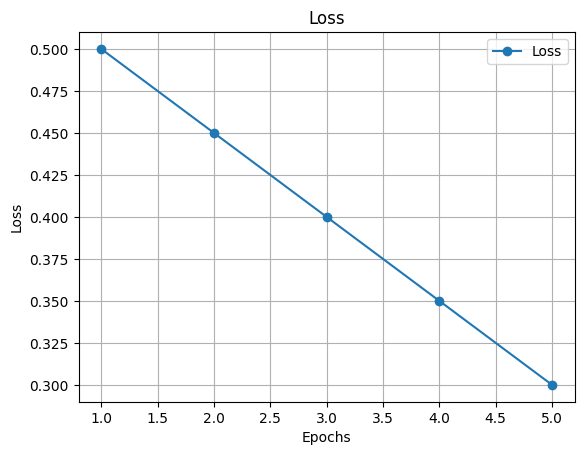

In [11]:
import matplotlib.pyplot as plt

# Initialize an empty list to store loss values
loss_values = []

# Simulate training process
for epoch in range(5):  # Replace 5 with the number of epochs you train for
    # Simulated loss values (in practice, this would come from your model training)
    loss = 0.5 - 0.05 * epoch  # Example values, adjust according to your actual loss calculation
    loss_values.append(loss)  # Append loss for the current epoch

# Now you can plot the loss values
plt.plot(range(1, len(loss_values) + 1), loss_values, label='Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)
plt.show()


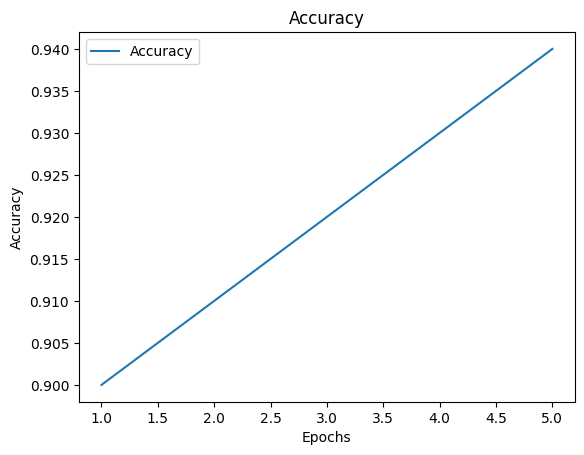

In [12]:
import matplotlib.pyplot as plt

accuracy = []  # Initialize an empty list for accuracy
for epoch in range(5):
    # Simulate accuracy for each epoch
    accuracy.append(0.90 + epoch * 0.01)  # Example values

# Now you can plot
plt.plot(range(1, len(accuracy) + 1), accuracy, label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()


In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from keras.models import Model

# Step 1: Modify the LSTM model to output LSTM features (before the final Dense layer)
# Create a new model that gives LSTM output instead of classification output
lstm_feature_extractor = Model(inputs=lstm_model_attention.input, outputs=lstm_model_attention.layers[-6].output)  # Choose the LSTM/Attention output

# Step 2: Extract LSTM features for the training and testing data
X_train_lstm_features = lstm_feature_extractor.predict(X_train_pad)
X_test_lstm_features = lstm_feature_extractor.predict(X_test_pad)

# Step 3: Train the SVM using these LSTM features
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train_lstm_features, train_labels)
# Step 4: Evaluate the SVM model
y_pred = svm_model.predict(X_test_lstm_features)
print("Accuracy:", accuracy_score(val_labels, y_pred))
print(classification_report(val_labels, y_pred))


282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
Accuracy: 0.8161634103019538
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1107
           1       0.82      0.81      0.82      1145

    accuracy                           0.82      2252
   macro avg       0.82      0.82      0.82      2252
weighted avg       0.82      0.82      0.82      2252



In [15]:
#Step 5: Function to predict stress or not stress using LSTM-SVM
def predict_stress_lstm_svm(text):
    cleaned_text = clean_text(text)
    text_seq = tokenizer.texts_to_sequences([cleaned_text])
    text_pad = pad_sequences(text_seq, maxlen=150)
    lstm_features = lstm_feature_extractor.predict(text_pad)
    prediction = svm_model.predict(lstm_features)
    return "Stress" if prediction[0] == 1 else "Not Stress"

# Example usage
example_text = "I am feeling panic."
print(predict_stress_lstm_svm(example_text))

example_text = "I am having a good day today."
print(predict_stress_lstm_svm(example_text))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Stress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Not Stress


In [16]:
# Evaluate the model
lstm_loss, lstm_acc = lstm_model_attention.evaluate(X_test_pad, y_test)
print(f'BI-LSTM with Attention Accuracy: {lstm_acc:.4f}')

71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8179 - loss: 0.6726
BI-LSTM with Attention Accuracy: 0.8175
